In [78]:
import pandas as pd
fish = pd.read_csv("fish.csv", encoding = "cp949")

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns


In [80]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [81]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


""" 컬럼 정보
 Species  생선의 종류 (분류형)
 Weight   생선의 무게 (수치형)
 Length   생선의 길이 (수치형)
 Diagonal 생선의 대각선 길이 (수치형)
 Height   생선의 크기 (수치형)
"""
None

In [82]:
# Species 에는 어떠한 것들이 있나?
fish.Species.unique()


<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

In [83]:
fish.count()

Species     159
Weight      159
Length      159
Diagonal    159
Height      159
Width       159
dtype: int64

In [84]:
fish.Species.value_counts() #데이터별로 몇개가 있는지 

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [85]:
bream_length = fish[fish.Species == "Bream"]['Length'].to_list()
bream_weight = fish[fish.Species == "Bream"]['Weight'].to_list()

bream_length[:5], bream_weight[:5] # bream의 길이와 무게의 처음 5개씩 보기

([25.4, 26.3, 26.5, 29.0, 29.0], [242.0, 290.0, 340.0, 363.0, 430.0])

Fish(생선) 분류 (classification) 문제
생선의 길이(length) 와 무게 (weight) 만으로 생선의 종류(species) 를 자동으로 분류 가능할까?
분류할 생선
Bream '도미'
Smelt '빙어'

In [86]:
#column이 나타내는 물고기 (feature) 데이터의 특징을 표현 하는 요소 




feature
데이터의 특징/특성
데이터를 표현하는 성질

도미 와 빙어 데이터 준비 

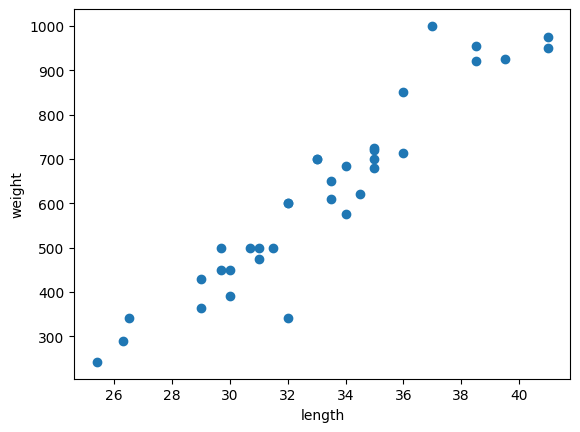

In [87]:
plt.scatter(bream_length, bream_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

도미의 데이터는 무게가 늘면 length 둘다 같이 커진다 

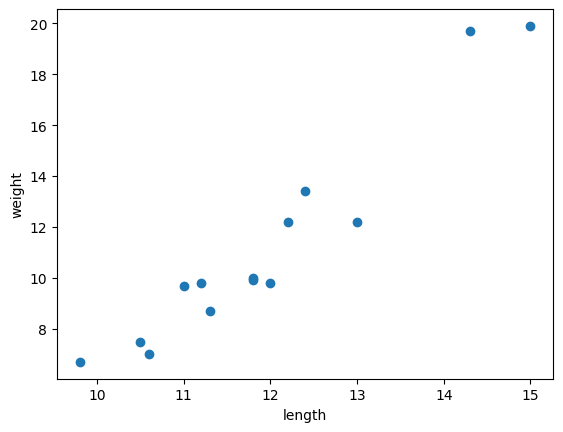

In [88]:
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


머신러닝의 입력(input) 데이터 준비
feature vector 형태로 준비하기

# 
# 앞서 준비한 도미와 빙어 데이터를 하나의 데이터로 합친다


bream_length = fish[fish.Species == "Bream"]['Length'].to_list()
bream_weight = fish[fish.Species == "Bream"]['Weight'].to_list()



length = bream_length + smelt_length
weight = bream_weight + smelt_weight

"""
scikit-learn 에선 '입력 data'를
각 '특성들' 의 '배열' 형태로 만들어야 한다 -> 2차원 배열

   길이   무게
[   ↓     ↓
  [25.4, 242.0],
  [26.3, 290.0],
  [26.5, 340.0],
  ...
  [15.0, 19.9]
]

- ★ 이를 '입력(input)' 이라고도 하고 'feature vector' 라고도 함.  이는 scikit-learn 뿐 아니라,
  대부분의 머신러닝 프레임워크에서도 이러한 방식의 input 을 사용한다.
"""
None

In [89]:
# 빙어 14 마리의 데이터

# 길이
smelt_length = fish[fish.Species == 'Smelt']['Length'].to_list()

# 무게
smelt_weight = fish[fish.Species == 'Smelt']['Weight'].to_list()

print(smelt_length)
print(smelt_weight)

[9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
[6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]


In [90]:
print(bream_length)
print(bream_weight)
print('-' * 20)
print(smelt_length)
print(smelt_weight)


[25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
[242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]
--------------------
[9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
[6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]


In [91]:
bream_length = fish[fish.Species == "Bream"]['Length'].to_list()
bream_weight = fish[fish.Species == "Bream"]['Weight'].to_list()

length = bream_length + smelt_length
weight = bream_weight + smelt_weight

In [92]:
"""
scikit-learn 에선 '입력 data'를
각 '특성들' 의 '배열' 형태로 만들어야 한다 -> 2차원 배열

   길이   무게
[   ↓     ↓
  [25.4, 242.0],
  [26.3, 290.0],
  [26.5, 340.0],
  ...
  [15.0, 19.9]
]

- ★ 이를 '입력(input)' 이라고도 하고 'feature vector' 라고도 함.  이는 scikit-learn 뿐 아니라,
  대부분의 머신러닝 프레임워크에서도 이러한 방식의 input 을 사용한다.
"""
None

In [93]:

fish_data = [[l, w] for l, w in zip(length, weight)]

print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


머신러닝의 모델 준비
모델(model) 이란
머신러닝 알고리즘을 구현한 프로그램,
혹은, 프로그램은 아니더라도 알고리즘을 (수식등으로) 구체화 하여 표현한 것.

In [94]:
from sklearn.neighbors import KNeighborsClassifier


In [95]:
# feature vector 형태로 입력데이터 만들기
fish_data = [[l, w] for l, w in zip(length, weight)]
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


In [96]:
# target , label 만들기 - 빙어는 0, 도미는 1로 표현하기
fish_target = [1] * 35 + [0] * 14
#빙어는 35 였고 도미는 14 였으니까
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [97]:
kn = KNeighborsClassifier()

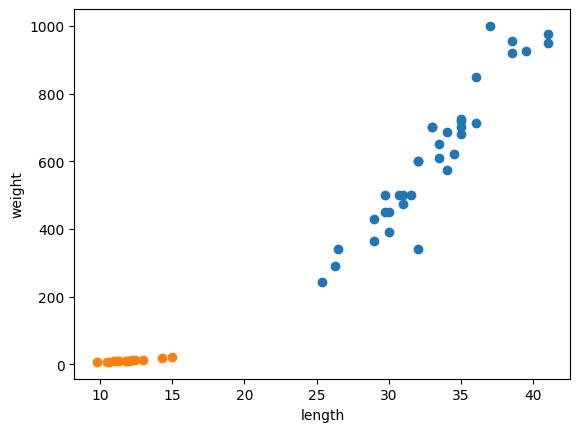

In [98]:
#knn 모델을 훈련시키기  주변의 가까운 데이터를 단정을 짓는거 
kn.fit(fish_data, fish_target)
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

    


In [99]:
# 모델 학습하기 
kn.fit(fish_data, fish_target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [100]:
# 정확한 accuracy 확인 을 하여 확인을 하는 것 
kn.score(fish_data, fish_target)

# 1.0이 나왔는데 이것은 점수가 100점으로 나왔다는 것 

1.0

In [101]:
#predict 예측하기 
kn.predict([[25, 150]]) # 길이가 25, 무게가 150인 물고기는 도미인가? 빙어인가?

array([0])

In [102]:
# array 0은 지금 0이 도미 라는 것을 알수 있다 
kn.predict([[30,600],[16,30]])

array([1, 0])

In [103]:
#knn 속성 들여다보기 
print(kn._fit_X) # 입력 데이터
print(kn._y) # 타겟 데이터

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]


In [104]:
n_neightbor = kn.n_neighbors
print(n_neightbor)
# 기본값 5 개 만 나올수 있다 

5


In [105]:
kn49 = KNeighborsClassifier(n_neighbors=49)
kn49.fit(fish_data, fish_target)
kn49.score(fish_data, fish_target)

# 49개 중에 35개 맞추는 것 35/49 = 0.71 방어가 너무 많아서 오히려 점수가 낮아지는 것 49개 중에 35개 맞추는 것 35/49 = 0.71

0.7142857142857143

In [106]:
fish.Species.value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [107]:
# KNeighborsClassifier 의 매개변수들
# - n_neighbors: 이웃의 개수
# - p : 매개변수 거리 재는 방법.
#        1 - 맨해튼 거리
#        2 - 유클리디안 거리 (디폴트)

# - n_jobs: 사용할 CPU 코어 지정.   이웃간의 거리 계산속도를 높일수는 있지만 fit() 메소드에는 영향이 없다
#       1 - 기본값
#      -1 - 모든 CPU 코어 사용

In [108]:
# 과연 n_neighbors= 가 몇개일때부터 정확도(accuracy)   가 100% 에 미치지 못할까?
# 함 확인해보자

# 결과 예시]
#   18 0.9795918367346939  <=  n_neighbors 와 정확도 출력

In [109]:
fish.Species.value_counts()

kn49 = KNeighborsClassifier(n_neighbors=49)
kn49.fit(fish_data, fish_target)
kn49.score(fish_data, fish_target)

0.7142857142857143

In [110]:
kn = KNeighborsClassifier()
kn.fit(fish_data, fish_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [111]:
for n in range(5, 50):
    kn.n_neighbors = n
    score = kn.score(fish_data, fish_target)
    if score < 1.0:
        print(n, score)
        break

18 0.9795918367346939


In [112]:
kn = KNeighborsClassifier()
kn.fit(fish_data, fish_target)

for n in range(5, 50):
    # 최근접 이웃 개수 설정
    kn.n_neighbors = n

    # 점수 계산
    score = kn.score(fish_data, fish_target)

    # 100% 정확도에 미치지 못하는 이웃 개수 출력
    if score < 1:
      print(n, score)
      break

18 0.9795918367346939


훈련 세트 와 테스트 세트
주어진 '문제'와 '답안지' 로 열심히 공부해서 문제집 문제집 100점 맞으면 그 학생은 잘한다 할수 있나?

진짜 잘하는지는 '문제집에 없던 문제'들을 풀어도 점수가 좋아야 한다.

그래서 data 와 target을 학습(training) 하는데 다 집어 넣는 것이 아니라, 훈련세트와 테스트세트를 나누어서 모델 훈련 및 검증에 사용한다

훈련 (training) 세트 : 모델 훈련 용 데이터 셋
테스트 (test) 세트 : 모델 평가(검증) 용 데이터 셋

In [54]:
#샘플링 편향이란?
# 현재  도미(1) 와 빙어(0) 가 각각 35, 14 마리 있다.
# 일부 생선 데이터를 추출한걸 'sample(샘플)' 이라고 부른다

print(fish_data[4])

[29.0, 430.0]


"""

데이터의 처음 35개를 train 세트 (훈련세트),
나머지 14개를 test 세트 (테스트 세트)로 사용해보면 어떨까?

[
  [25.4, 242.0], ─┐
  [26.3, 290.0],  │ train 세트 35개
  [26.5, 340.0],  │
  ...            ─┘
  ...            ─┐
  ...             │ test 세트 14개
  [15.0, 19.9]   ─┘
]

"""
None

In [55]:
train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]
kn.fit(train_input, train_target) # 훈련용 데이터로 학습
kn.score(test_input, test_target) # test 용 으로 

0.0

In [58]:
import numpy as np

In [59]:
#데이터 shuffle 

# 여기선 numpy 를 사용하여 섞어 봅니다.
# ※나중에 scikit-learn 에서 사용하는 방법도 소개할 예정

input_arr = np.array(fish_data) 
target_arr = np.array(fish_target)


In [60]:
print(input_arr)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [62]:
input_arr.shape, target_arr.shape

((49, 2), (49,))

In [64]:
np.random.seed(42) # 랜덤 시드 고정
index = np.arange(input_arr.shape[0]) # 데이터 개수 만큼의 인덱스 배열 만들기
np.random.shuffle(index) # 인덱스 섞기
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


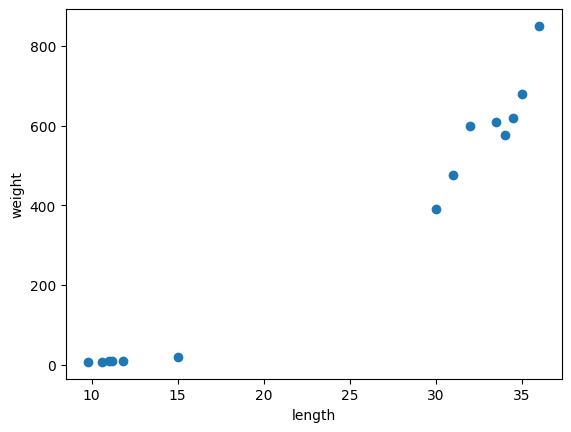

In [67]:
# test set 
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]
#test 세트와 train세트가 잘 섞여있는지 확인하기 위해서 test 세트와 train 세트의 target 값의 분포를 확인해보자
plt.scatter(test_input[:, 0], test_input[:, 1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


In [68]:
#훈련은 train 세트로 
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [69]:
kn.score(test_input, test_target)

0.5714285714285714

데이터 전처리 

In [70]:
# 과연 지금까지 모델은 괜찮은지 
# 길이 25 cm 무개 150 인 물고기는 도미인가? 빙어인가?
kn.predict([[25, 150]])


array([1])

In [71]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(test_input[:, 0], test_input[:, 1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

TypeError: list indices must be integers or slices, not tuple

In [ ]:
fish_target = np.concatenate([np.ones(35), np.zeros(14)])
#도미 35 방어14 마리 데이터 직전에 1 * 35 + 0 * 14 = 35 개의 1과 14 개의 0이 있는 배열 만들기

In [73]:
fish_target

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [74]:
#kneighbors

distances, indexes = kn.kneighbors([[25, 150]])
distances, indexes = kn.kneighbors([[25, 150]])

# kneighbors() 는 이웃까지의 거리(들)과 이웃 샘플에 대한 인덱스(들)을 리턴함
# 현재 n_neighbors 는 기본값 5 이기 때문에 5개의 neighbor 들이 리턴된다

In [75]:
distances 

array([[ 92.00086956, 140.00603558, 190.00592096, 190.12890364,
        213.03755537]])

In [76]:
indexes

array([[ 0,  1,  2, 13,  3]])

In [77]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker='^')

plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')  # neighbor 들을 따로 찍어보자 (마름모)

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

TypeError: list indices must be integers or slices, not tuple

In [113]:
kn.score(fish_data, fish_target)


0.9795918367346939

In [114]:
train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]

train_input 
train_target 

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [ ]:
kn.fit(train_input, train_target) # 훈련용 데이터로 학습
kn.score(test_input, test_target) # test 용 으로

0.0

In [ ]:
distances, indexes = kn.kneighbors([[25, 150]])
distances, indexes = kn

regression 은 무엇일까 
임의의 수치가 되어야됨 
100 + 80 + 60 /3 이런 평균을 구할수 있는 것 

In [116]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os 


In [117]:
#농어는 perch 의 길이 특징 ,feature 가 주어졌을떄 무게 를 예측 
perch_length = fish[fish.Species == 'Perch']['Length'].to_list()
perch_weight = fish[fish.Species == 'Perch']['Weight'].to_list()

#농어의 무개 
perch_weight =  fish[fish.Species == 'Perch']['Weight'].to_list()
print(perch_length)

[8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5, 44.0]


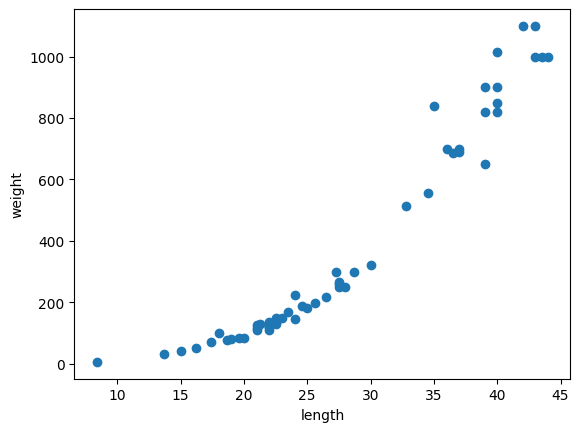

In [118]:
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor()

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

In [121]:
print(train_input.shape, test_input.shape)

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
#KNeighborsRegressor 는 KNeighborsClassifier 와 달리 회귀 문제에 사용하는 모델이다.  KNeighborsClassifier 는 분류 문제에 사용하는 모델이었다.  회귀 문제는 예측하려는 타겟이 연속적인 숫자값인 문제를 말한다.  분류 문제는 예측하려는 타겟이 범주형 값인 문제를 말한다.  KNeighborsRegressor 는 주변의 이웃들의 타겟값을 평균내어서 예측값을 구하는 방식으로 작동한다.

In [124]:
Kn.fit(train_input, train_target)


NameError: name 'Kn' is not defined

In [125]:
perch_length = fish[fish.Species == 'Perch']['Length'].to_list()

In [126]:
perch_length 

[8.4,
 13.7,
 15.0,
 16.2,
 17.4,
 18.0,
 18.7,
 19.0,
 19.6,
 20.0,
 21.0,
 21.0,
 21.0,
 21.3,
 22.0,
 22.0,
 22.0,
 22.0,
 22.0,
 22.5,
 22.5,
 22.7,
 23.0,
 23.5,
 24.0,
 24.0,
 24.6,
 25.0,
 25.6,
 26.5,
 27.3,
 27.5,
 27.5,
 27.5,
 28.0,
 28.7,
 30.0,
 32.8,
 34.5,
 35.0,
 36.5,
 36.0,
 37.0,
 37.0,
 39.0,
 39.0,
 39.0,
 40.0,
 40.0,
 40.0,
 40.0,
 42.0,
 43.0,
 43.0,
 43.5,
 44.0]

In [ ]:
#모델은 train 세트로 훈련하면 train 세트에 잘 맞는 모델이 만들어진다 

In [127]:
#회귀 

class sklarn.preprocessing.StandardScaler():
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0)

    def transform(self, X):
        return (X - self.mean_) / self.scale_

SyntaxError: invalid syntax (513029080.py, line 3)